In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons

X, y = make_moons(500, random_state=52, noise=0.4)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=52)

voting_cls = VotingClassifier([('rf', RandomForestClassifier(random_state=52)), 
                               ('lr', LogisticRegression(random_state=52)), 
                               ('svc', SVC(random_state=52))])

voting_cls.fit(X_train, y_train)

,estimators,"[('rf', ...), ('lr', ...), ...]"
,voting,'hard'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1


In [3]:
for name, clf in voting_cls.named_estimators_.items():
    print(name, '=', clf.score(X_test, y_test))

rf = 0.872
lr = 0.88
svc = 0.896


In [4]:
for name, clf in voting_cls.named_estimators_.items():
    print(name, '=', clf.predict(X_test[7:8]))
    
print('vote is:', voting_cls.predict(X_test[7:8]))

rf = [0]
lr = [1]
svc = [0]
vote is: [0]


In [5]:
voting_cls.score(X_test, y_test)

0.888

In [6]:
#soft voting
voting_cls.voting = 'soft'
voting_cls.named_estimators['svc'].probability = True
voting_cls.fit(X_test, y_test)
voting_cls.score(X_test, y_test)

0.912

## Bagging

In [7]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bg_cls = BaggingClassifier(DecisionTreeClassifier(), n_estimators=500, n_jobs=-1, max_samples=100, bootstrap=True, random_state=52) #pasting -> bootstrap=False

bg_cls.fit(X_train, y_train)

,estimator,DecisionTreeClassifier()
,n_estimators,500
,max_samples,100
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,-1
,random_state,52
,verbose,0


In [8]:
#bagging
from sklearn.model_selection import cross_val_score
cross_val_score(bg_cls, X_train, y_train, cv=5, scoring='accuracy')

array([0.86666667, 0.89333333, 0.74666667, 0.84      , 0.84      ])

In [9]:
#pasting
cross_val_score(bg_cls, X_train, y_train, cv=5, scoring='accuracy')

array([0.86666667, 0.89333333, 0.74666667, 0.84      , 0.84      ])

### OOB

In [10]:
oob_bag_cls = BaggingClassifier(DecisionTreeClassifier(), oob_score=True, n_estimators=500, random_state=52, n_jobs=-1, bootstrap=True)

oob_bag_cls.fit(X_train, y_train)
oob_bag_cls.oob_score_

0.8026666666666666

In [11]:
oob_bag_cls.score(X_test, y_test)

0.848

In [12]:
from sklearn.metrics import accuracy_score
y_pred = oob_bag_cls.predict(X_test)
accuracy_score(y_test, y_pred)

0.848

In [13]:
oob_bag_cls.oob_decision_function_[:10]

array([[0.89473684, 0.10526316],
       [0.5625    , 0.4375    ],
       [0.97282609, 0.02717391],
       [0.14      , 0.86      ],
       [0.07647059, 0.92352941],
       [0.48314607, 0.51685393],
       [0.82248521, 0.17751479],
       [0.39423077, 0.60576923],
       [1.        , 0.        ],
       [0.3956044 , 0.6043956 ]])

# Random forests

In [14]:
from sklearn.ensemble import RandomForestClassifier

forest_cls = RandomForestClassifier(n_estimators=500, max_leaf_nodes=16, n_jobs=-1, random_state=52)

forest_cls.fit(X_train, y_train)
forest_cls.score(X_test, y_test)

0.888

In [15]:
forest_bag = BaggingClassifier(DecisionTreeClassifier(max_features='sqrt', max_leaf_nodes=16), n_estimators=500, n_jobs=-1, random_state=52)

forest_bag.fit(X_train, y_train)
forest_bag.score(X_test, y_test)

0.896

In [16]:
#extra trees
from sklearn.ensemble import ExtraTreesClassifier

extra_trees = ExtraTreesClassifier(n_estimators=500, max_leaf_nodes=16, n_jobs=-1, random_state=52)

extra_trees.fit(X_train, y_train)
extra_trees.score(X_test, y_test)

0.888

features importance

In [17]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)

rf_cls = RandomForestClassifier(random_state=52)
rf_cls.fit(iris.data, iris.target)

for score, name in zip(rf_cls.feature_importances_, iris.data.columns):
    print(name, score.round(3))

sepal length (cm) 0.122
sepal width (cm) 0.025
petal length (cm) 0.395
petal width (cm) 0.459


## Boosting

In [21]:
# adaboost
from sklearn.ensemble import AdaBoostClassifier

ada_boost = AdaBoostClassifier(DecisionTreeClassifier(max_depth=1), n_estimators=40, algorithm='SAMME', random_state=52, learning_rate=0.5)

ada_boost.fit(X_train, y_train)
ada_boost.score(X_test, y_test)

/home/damian/test/.venv/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


0.896

Gradient Boosting

In [26]:
# GB by myself
from sklearn.tree import DecisionTreeRegressor

m = 200
rng = np.random.default_rng()
noise = rng.standard_normal(m) * 0.05
X = rng.random((m, 1)) - 0.5
y = 3*X[:,0]**2 + noise

tree_reg1 = DecisionTreeRegressor(max_depth=2, random_state=52)
tree_reg1.fit(X, y)

,criterion,'squared_error'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,52
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [27]:
y2 = y - tree_reg1.predict(X)
tree_reg2 = DecisionTreeRegressor(max_depth=2, random_state=52)
tree_reg2.fit(X, y2)

,criterion,'squared_error'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,52
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [28]:
y3 = y2 - tree_reg2.predict(X)
tree_reg3 = DecisionTreeRegressor(max_depth=2, random_state=52)
tree_reg3.fit(X, y3)

,criterion,'squared_error'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,52
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [31]:
X_new = np.array([[0.4], [-0.5], [0.02]])

sum(tree.predict(X_new) for tree in (tree_reg1, tree_reg2, tree_reg3))    

array([0.51961526, 0.66584876, 0.03481088])

Text(0.5, 1.0, 'GB 3 trees')

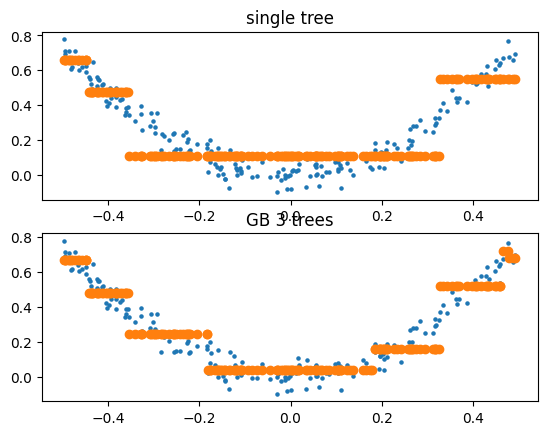

In [ ]:
plt.subplot(211)
plt.scatter(X, y, s=5)
plt.scatter(X, (tree_reg1.predict(X)))
plt.title('single tree')
plt.subplot(212)
plt.scatter(X, y, s=5)
plt.scatter(X, sum(tree.predict(X) for tree in (tree_reg1, tree_reg2, tree_reg3)))
plt.title('GB 3 trees')

In [54]:
from sklearn.ensemble import GradientBoostingRegressor

gb_reg = GradientBoostingRegressor(max_depth=2, random_state=52, n_estimators=500, n_iter_no_change=10, learning_rate=0.05)
gb_reg.fit(X, y)
gb_reg.n_estimators_

91

0.9680547897318017

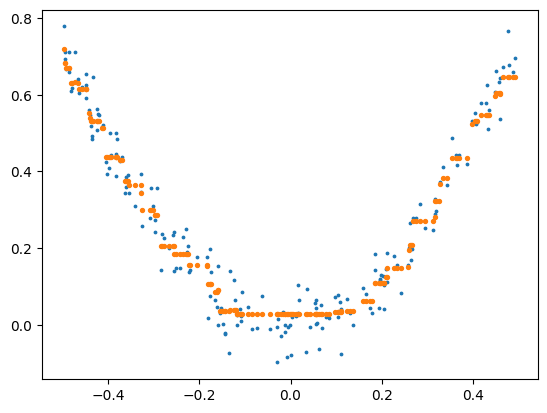

In [58]:
plt.scatter(X, y, s=3)
plt.scatter(X, gb_reg.predict(X), s=8)

gb_reg.score(X, y)

## Stacking

In [59]:
X, y = make_moons(500, random_state=52, noise=0.4)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=52)

In [64]:
from sklearn.ensemble import StackingClassifier

stack_cls = StackingClassifier(estimators=[('rf', RandomForestClassifier(random_state=52)),
                                ('lg', LogisticRegression(random_state=52)), 
                                ('svc', SVC(probability=True,random_state=52))], final_estimator=RandomForestClassifier(random_state=111), cv=5)

stack_cls.fit(X_train, y_train)

,estimators,"[('rf', ...), ('lg', ...), ...]"
,final_estimator,RandomForestC...dom_state=111)
,cv,5
,stack_method,'auto'
,n_jobs,None
,passthrough,False
,verbose,0
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2


In [65]:
stack_cls.score(X_test, y_test)

0.888